In [1]:
pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = sns.load_dataset("tips")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


Dataset Understanding

In [4]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [5]:
df.shape

(244, 7)

In [6]:
df.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')

In [7]:
df.dtypes

total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

In [8]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [9]:
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [10]:
df.select_dtypes(include='object').nunique()

Series([], dtype: float64)

In [11]:
df.select_dtypes(include='number').columns

Index(['total_bill', 'tip', 'size'], dtype='object')

In [12]:
target = "tip"

Distribution Plots

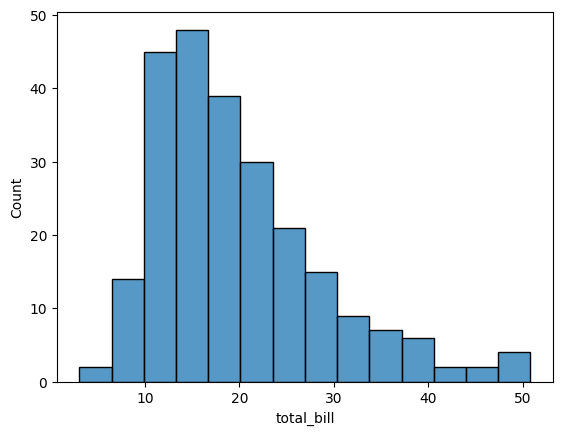

In [13]:
sns.histplot(df["total_bill"])
plt.show()

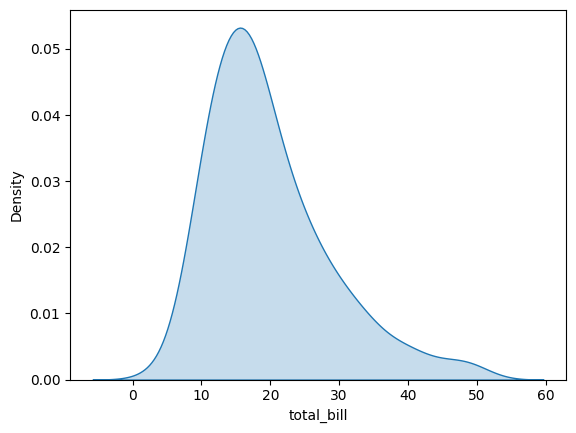

In [14]:
sns.kdeplot(df["total_bill"], fill=True)
plt.show()

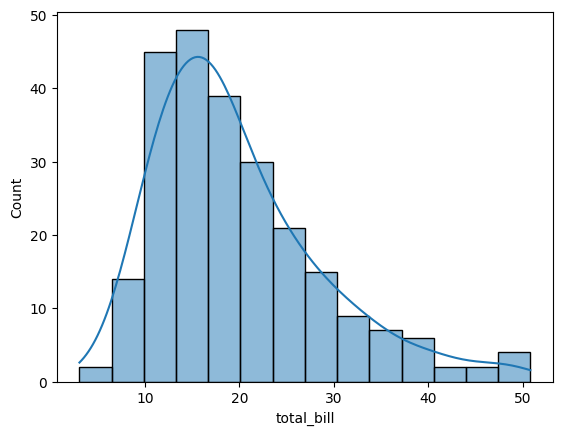

In [15]:
sns.histplot(df["total_bill"], kde=True)
plt.show()

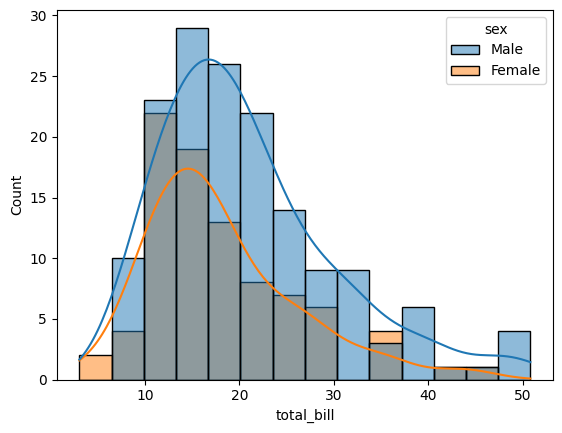

In [16]:
sns.histplot(data=df, x="total_bill", hue="sex", kde=True)
plt.show()

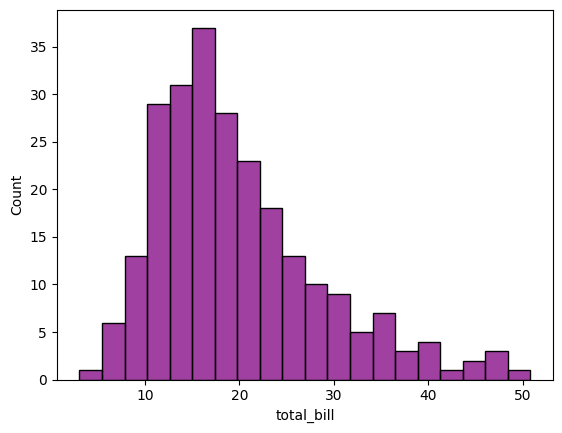

In [17]:
sns.histplot(df["total_bill"], bins=20, color="purple")
plt.show()

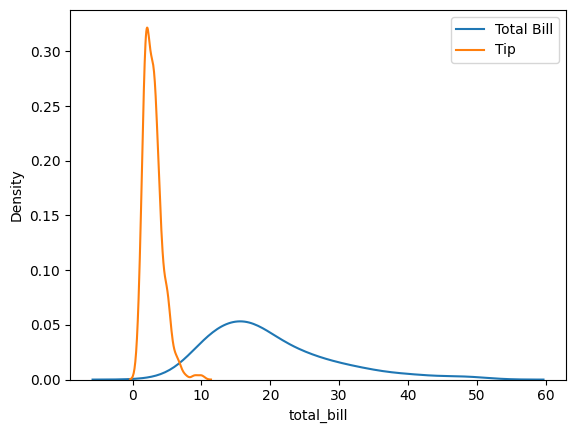

In [18]:
sns.kdeplot(df["total_bill"], label="Total Bill")
sns.kdeplot(df["tip"], label="Tip")

plt.legend()
plt.show()

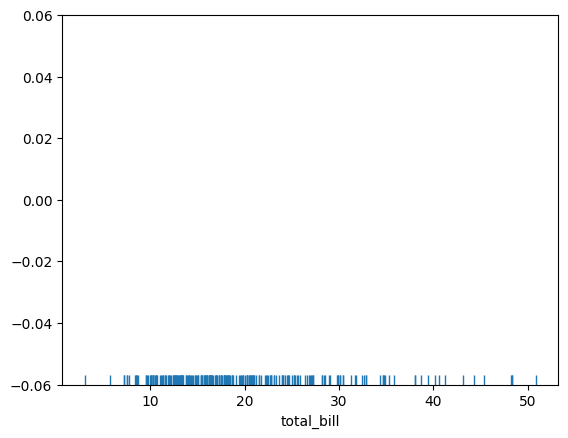

In [19]:
sns.rugplot(df["total_bill"])
plt.show()

In [20]:
df["total_bill"].skew()

np.float64(1.1332130376158205)

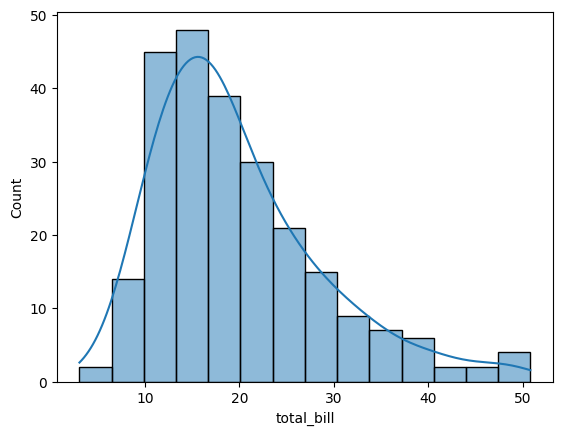

In [21]:
sns.histplot(df["total_bill"], kde=True)

plt.savefig("distribution_plot.png")
plt.show()

Categorical Data Visualization

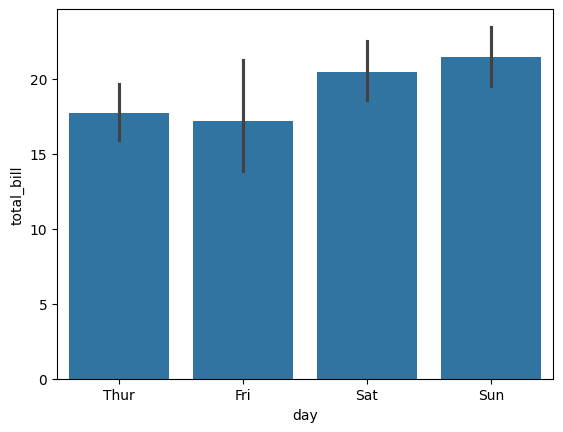

In [22]:
sns.barplot(x="day", y="total_bill", data=df)
plt.show()

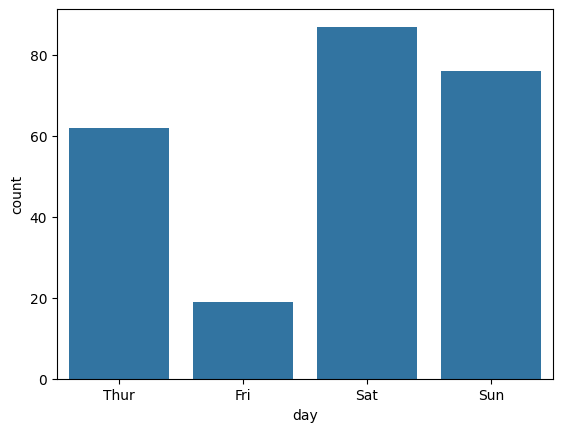

In [23]:
sns.countplot(x="day", data=df)
plt.show()

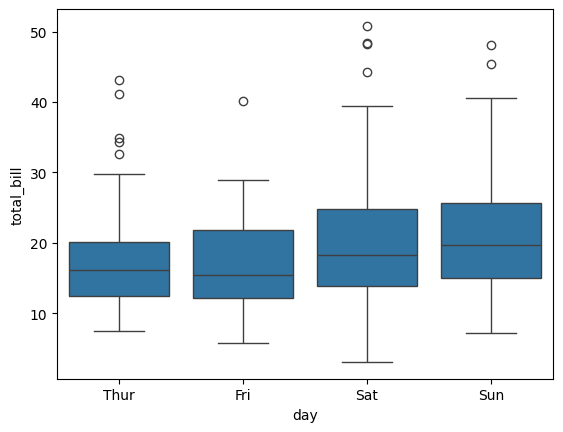

In [24]:
sns.boxplot(x="day", y="total_bill", data=df)
plt.show()

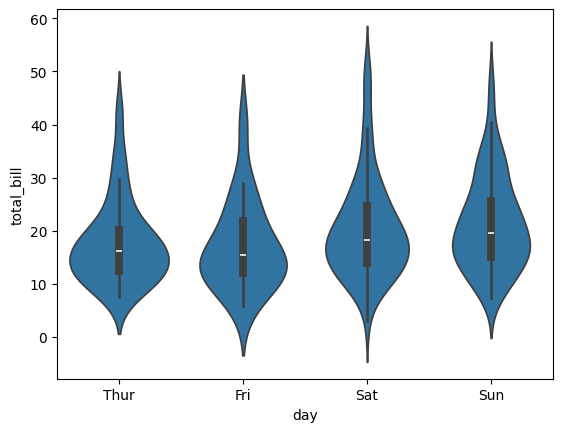

In [25]:
sns.violinplot(x="day", y="total_bill", data=df)
plt.show()

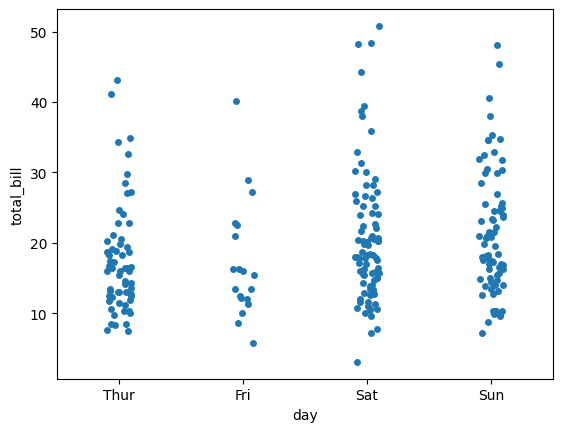

In [26]:
sns.stripplot(x="day", y="total_bill", data=df)
plt.show()

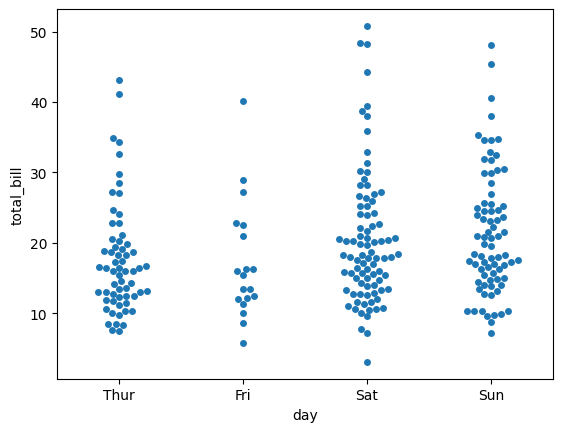

In [27]:
sns.swarmplot(x="day", y="total_bill", data=df)
plt.show()

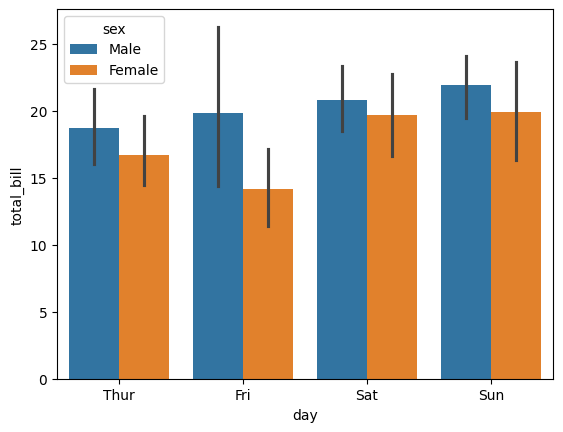

In [28]:
sns.barplot(x="day", y="total_bill", hue="sex", data=df)
plt.show()

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0.0, 0, '0.0'),
  Text(0.2, 0, '0.2'),
  Text(0.4, 0, '0.4'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.8, 0, '0.8'),
  Text(1.0, 0, '1.0')])

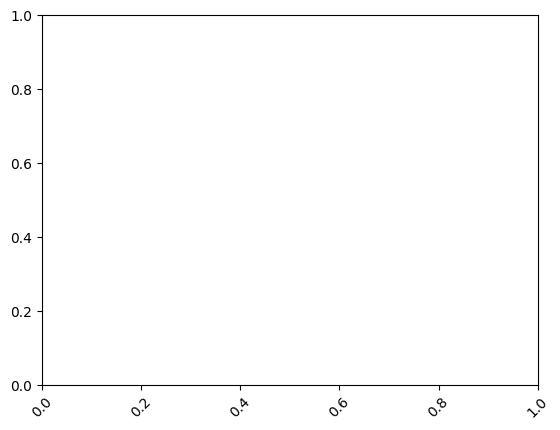

In [29]:
plt.xticks(rotation=45)

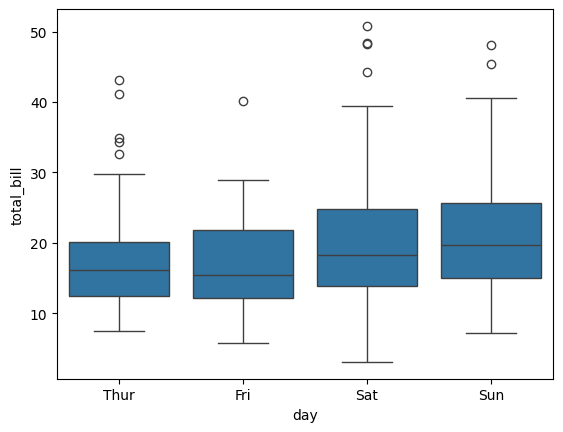

In [30]:
sns.boxplot(x="day", y="total_bill", data=df)
plt.show()

Relationship Plots

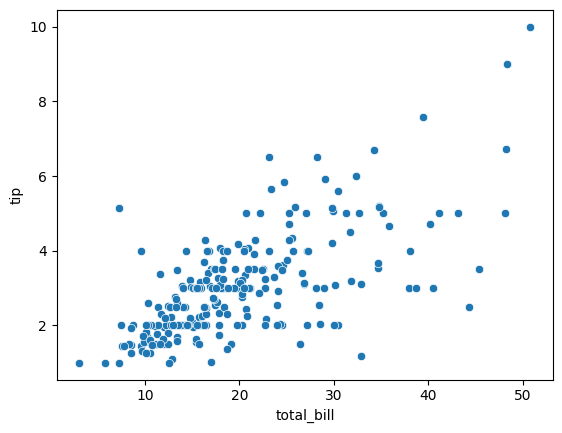

In [31]:
sns.scatterplot(x="total_bill", y="tip", data=df)
plt.show()

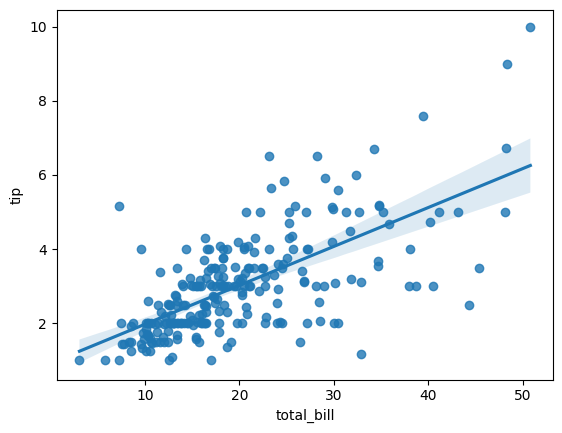

In [32]:
sns.regplot(x="total_bill", y="tip", data=df)
plt.show()

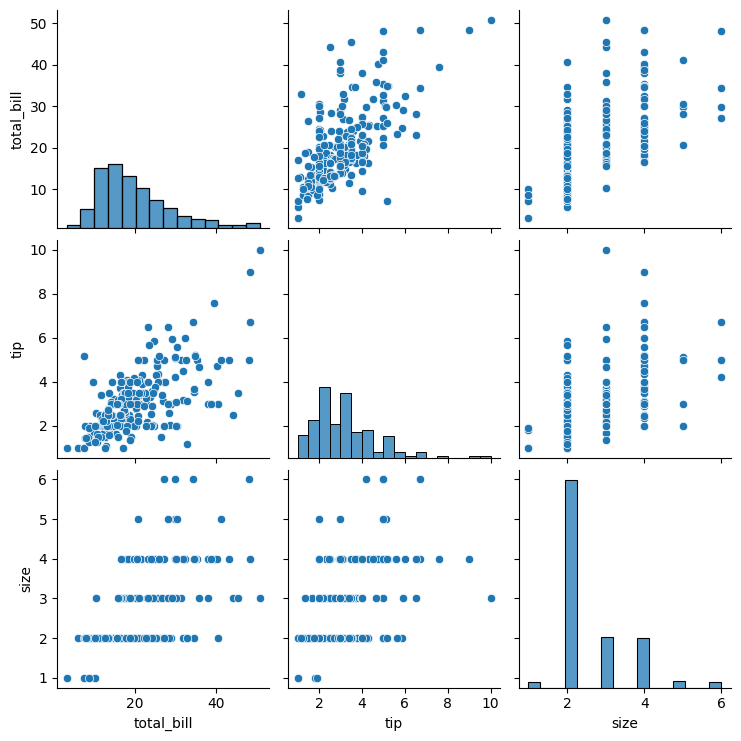

In [33]:
sns.pairplot(df)
plt.show()

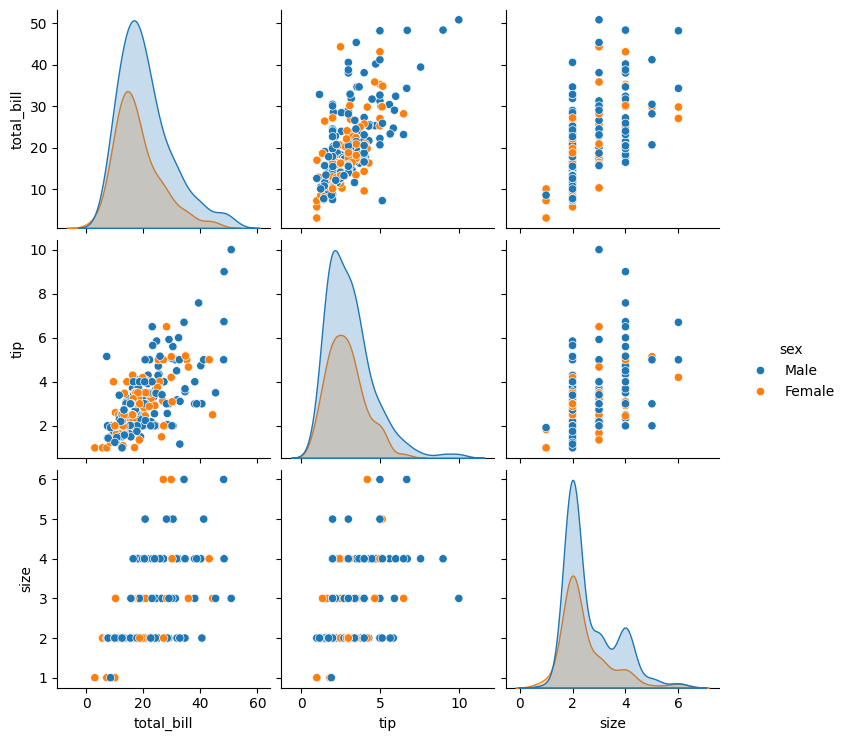

In [34]:
sns.pairplot(df, hue="sex")
plt.show()

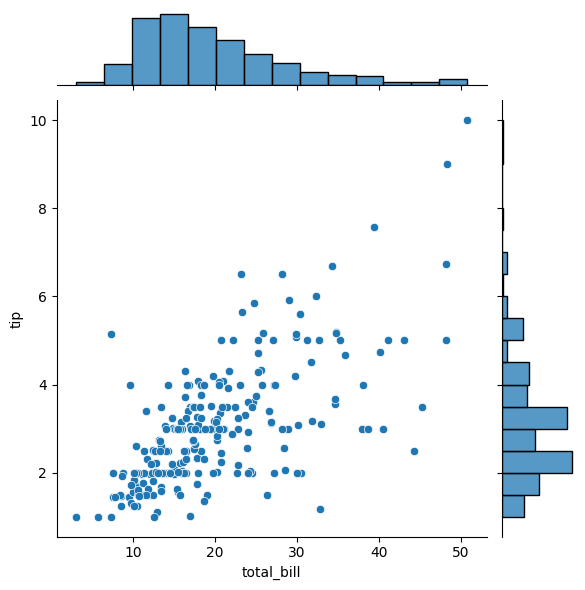

In [35]:
sns.jointplot(x="total_bill", y="tip", data=df)
plt.show()

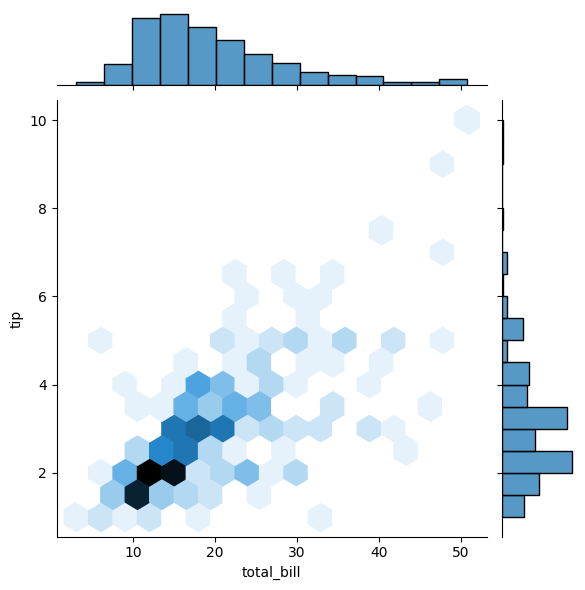

In [36]:
sns.jointplot(x="total_bill", y="tip", data=df, kind="hex")
plt.show()

In [37]:
df.corr(numeric_only=True)

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


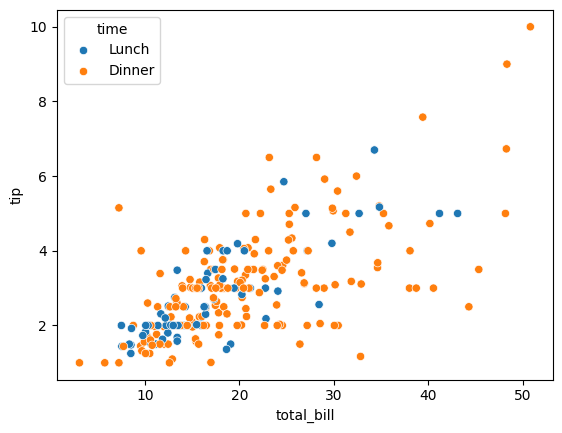

In [38]:
sns.scatterplot(x="total_bill", y="tip", hue="time", data=df)
plt.show()

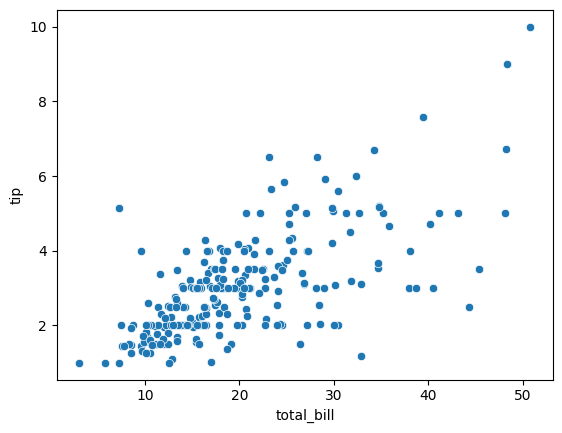

In [39]:
sns.scatterplot(x="total_bill", y="tip", data=df)

plt.savefig("relationship_plot.png")

Heatmap and Matrix Plots

In [40]:
corr = df.corr(numeric_only=True)

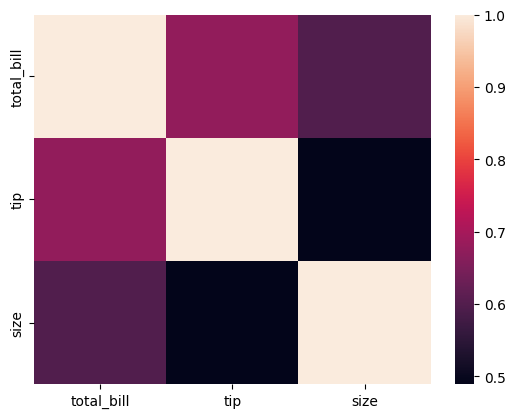

In [41]:
sns.heatmap(corr)
plt.show()

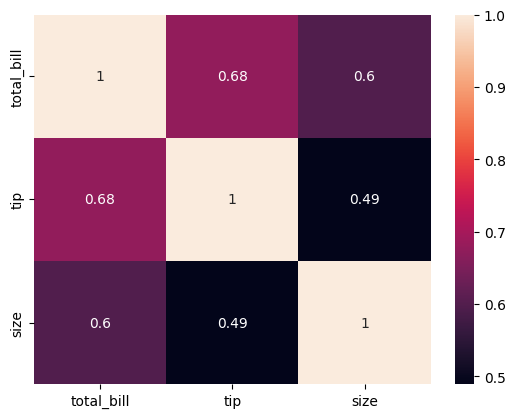

In [42]:
sns.heatmap(corr, annot=True)
plt.show()

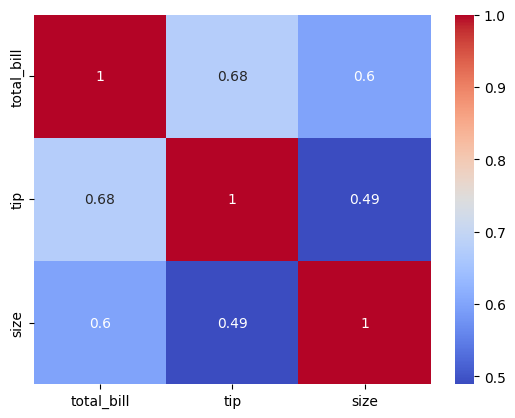

In [43]:
sns.heatmap(corr, cmap="coolwarm", annot=True)
plt.show()

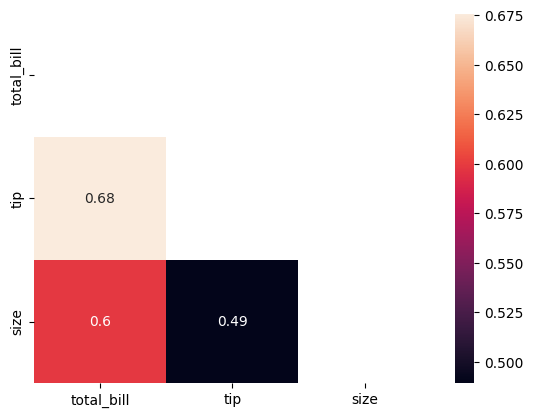

In [44]:
import numpy as np

mask = np.triu(corr)

sns.heatmap(corr, mask=mask, annot=True)
plt.show()

In [50]:
import sys
print(sys.executable)

/home/codespace/.python/current/bin/python


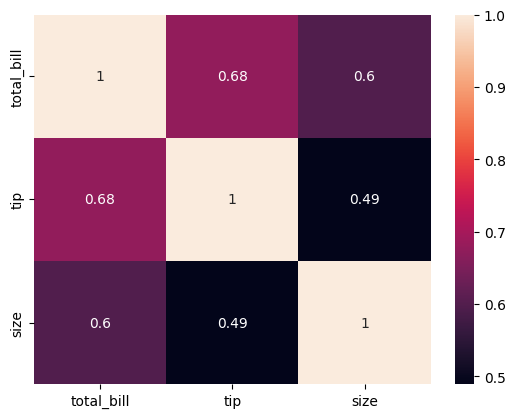

In [51]:
sns.heatmap(corr, annot=True)

plt.savefig("heatmap.png")

Part B: Advanced Seaborn

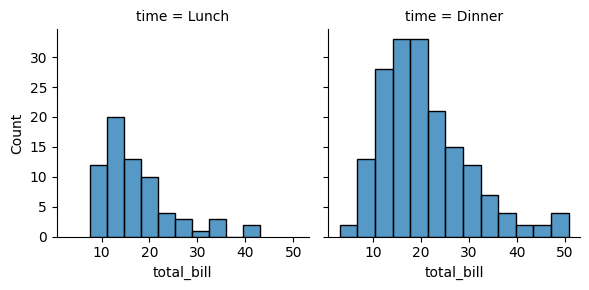

In [52]:
g = sns.FacetGrid(df, col="time")
g.map(sns.histplot, "total_bill")

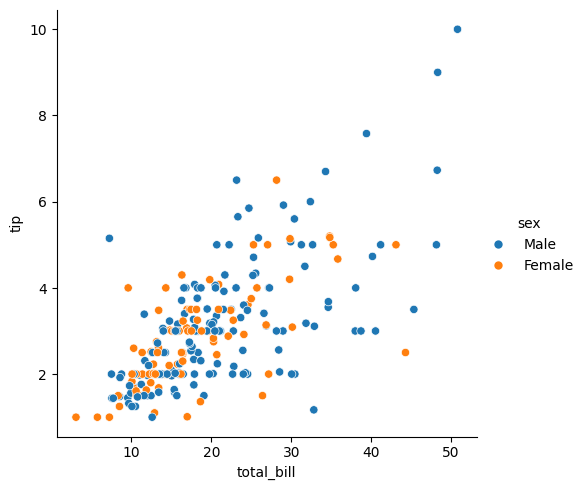

In [53]:
sns.relplot(x="total_bill", y="tip", hue="sex", data=df)

<Axes: xlabel='size', ylabel='total_bill'>

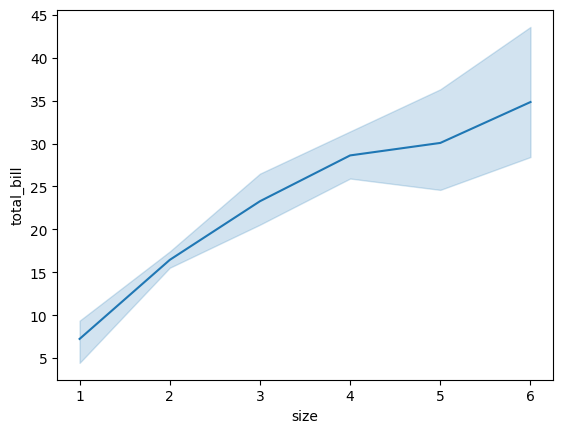

In [54]:
sns.lineplot(x="size", y="total_bill", data=df)

/tmp/ipykernel_13879/2939706372.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(x="size", y="total_bill", data=df, ci=95)


<Axes: xlabel='size', ylabel='total_bill'>

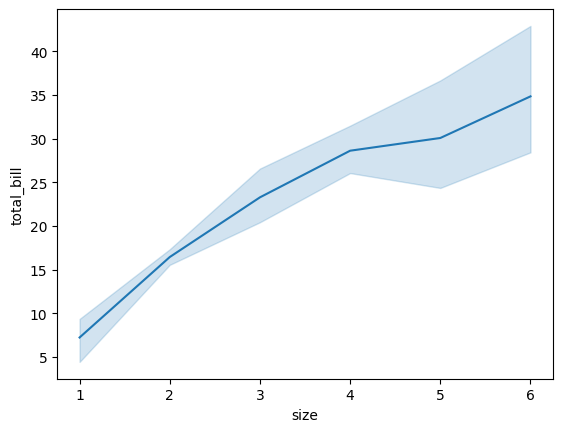

In [55]:
sns.lineplot(x="size", y="total_bill", data=df, ci=95)

In [56]:
df.groupby("day")["total_bill"].mean()

/tmp/ipykernel_13879/2472984912.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("day")["total_bill"].mean()


day
Thur    17.682742
Fri     17.151579
Sat     20.441379
Sun     21.410000
Name: total_bill, dtype: float64

<Axes: xlabel='day', ylabel='tip'>

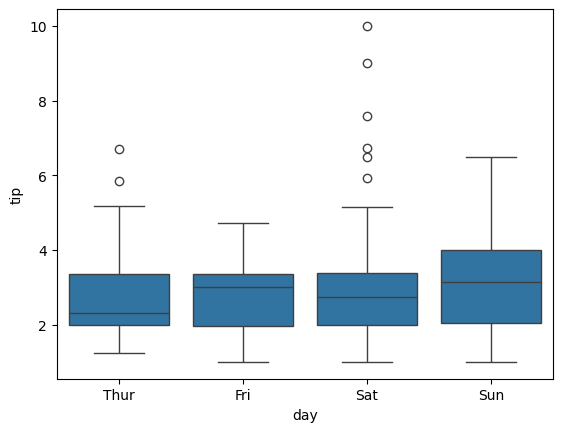

In [57]:
sns.boxplot(x="day", y="tip", data=df)

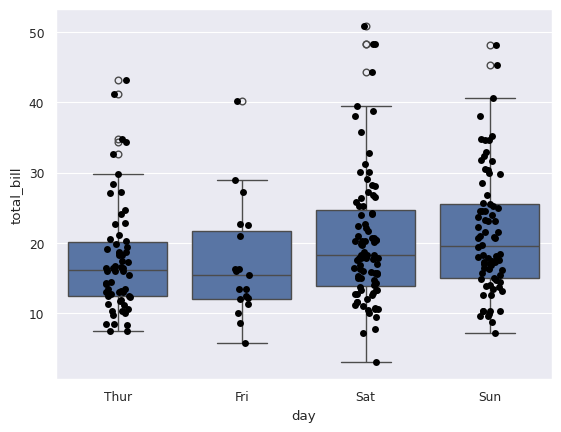

In [61]:
sns.boxplot(x="day", y="total_bill", data=df)
sns.stripplot(x="day", y="total_bill", data=df, color="black")
sns.set_theme(style="darkgrid")

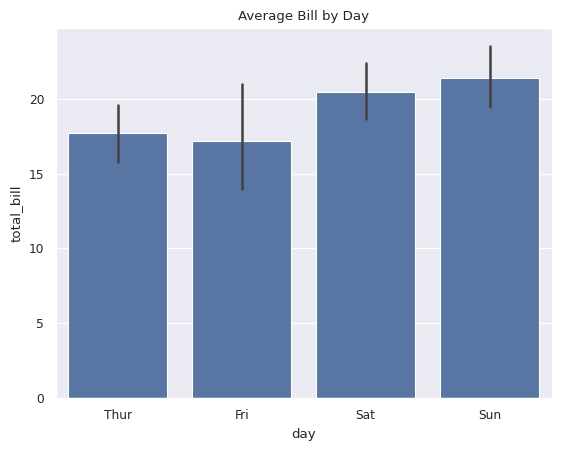

In [60]:
sns.set_context("paper")

sns.barplot(x="day", y="total_bill", data=df)

plt.title("Average Bill by Day")
plt.show()